# 5.0 — Data Preparation (Beta = 5e^-5)

## What this notebook does
1. Loads train and val latent vector files (β = 3×10⁻⁵) separately
2. Extracts scan date from file_path (no EVENT_ID in new files)
3. Loads and preprocesses UPDRS-III (OFF state, NP3TOT) and MoCA
4. Merges clinical data using PATNO + scan date
5. Checks patient overlap between train and val files
6. Fits SBR PCA once on training set and saves fitted objects
7. Runs inter-clinical variable correlation check
8. Saves final train.csv and val.csv



## 1. Imports and Configuration

In [83]:
# [IMPORTS]
import pandas as pd
import numpy as np
import pickle
import os
import re
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [84]:
# [CONFIG]
# File paths
LATENT_TRAIN_FILE = '../../data/baseline/train_mu_beta_5.00e-05.csv'
LATENT_VAL_FILE   = '../../data/baseline/val_mu_beta_5.00e-05.csv'
KL_DIVERGENCE_FILE = '../../data/baseline/kl_divergence_beta_5.00e-05.csv' 
BETA = '5.00e-05'

CLINICAL_DIR   = '../../data/raw/ppmi_clinical/'
UPDRS_III_FILE = os.path.join(CLINICAL_DIR, 'MDS-UPDRS_Part_III_06Jul2026.csv')
MOCA_FILE      = os.path.join(CLINICAL_DIR, 'Montreal_Cognitive_Assessment__MoCA__08Jul2026.csv')

TRAIN_OUT  = '../../data/processed/clinical_merged/train_beta_5e5.csv'
VAL_OUT    = '../../data/processed/clinical_merged/val_beta_5e5.csv'
SCALER_OUT = '../../results/models/scaler_sbr_beta_5e5.pkl'
PCA_OUT    = '../../results/models/pca_sbr_beta_5e5.pkl'

os.makedirs('../../data/processed/clinical_merged', exist_ok=True)
os.makedirs('../../results/models', exist_ok=True)

# Parameters
PATIENT_COL  = 'PATNO'
LABEL_COL    = 'label'
RANDOM_STATE = 42
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]
N_SBR_PCS = 3

print("Configuration loaded.")

Configuration loaded.


In [85]:
# Inspect the data
df_train = pd.read_csv(LATENT_TRAIN_FILE)
df_val   = pd.read_csv(LATENT_VAL_FILE)
df_kl    = pd.read_csv(KL_DIVERGENCE_FILE)

overlap  = set(df_train['PATNO']) & set(df_val['PATNO'])
active   = df_kl[df_kl['mean_kl'] > 0.05]

print(f"Beta: {BETA}")
print(f"Train: {df_train.shape}, {df_train['PATNO'].nunique()} patients")
print(f"Val:   {df_val.shape}, {df_val['PATNO'].nunique()} patients")
print(f"Overlap: {len(overlap)}")
print(f"Active dims: {len(active)} / 256 ({(256-len(active))/256*100:.1f}% collapse)")
print()
 

Beta: 5.00e-05
Train: (3085, 259), 1678 patients
Val:   (784, 259), 420 patients
Overlap: 0
Active dims: 50 / 256 (80.5% collapse)



## 2. Helper Functions

In [86]:
# [HELPER-FUNCTIONS] — simplified version without in-place assignment

def extract_scan_month(df, filepath_col='file_path'):
    """
    Extract scan month (MM/YYYY) from file path.
    Drops rows with invalid placeholder dates (9999-xx-xx).
    """
    df = df.copy()
    df['scan_date'] = df[filepath_col].str.extract(r'(\d{4}-\d{2}-\d{2})')
    valid_mask = ~df['scan_date'].str.startswith('9999', na=True)
    n_dropped  = (~valid_mask).sum()
    df = df[valid_mask].copy().reset_index(drop=True)
    df['scan_month'] = pd.to_datetime(
        df['scan_date'], format='%Y-%m-%d'
    ).dt.strftime('%m/%Y')
    print(f"  Date extraction: {len(df)} valid rows, {n_dropped} invalid dropped")
    return df


def merge_on_date(df_base, df_clinical, clinical_cols,
                  base_date_col='scan_month',
                  clinical_date_col='INFODT',
                  label='clinical'):
    """
    Merge df_base with df_clinical on PATNO + visit date (MM/YYYY).
    Two-step approach:
      1. Exact match on PATNO + date
      2. ±1 month fallback for unmatched rows
    Avoids in-place assignment by doing two separate merges and combining.
    """
    df_base     = df_base.reset_index(drop=True)
    df_clinical = df_clinical.copy()

    # Standardise clinical date to MM/YYYY
    df_clinical[clinical_date_col] = pd.to_datetime(
        df_clinical[clinical_date_col], format='%m/%Y', errors='coerce'
    ).dt.strftime('%m/%Y')

    # Deduplicate — one record per PATNO + date
    df_clinical = df_clinical.drop_duplicates(
        subset=['PATNO', clinical_date_col], keep='first'
    ).reset_index(drop=True)

    cols_to_merge = ['PATNO', clinical_date_col] + clinical_cols

    # Step 1 — exact date match
    matched = df_base.merge(
        df_clinical[cols_to_merge].rename(columns={clinical_date_col: base_date_col}),
        on=['PATNO', base_date_col],
        how='inner'
    )
    n_exact = len(matched)

    # Rows not matched in step 1
    matched_idx   = df_base.merge(
        df_clinical[['PATNO', clinical_date_col]].rename(
            columns={clinical_date_col: base_date_col}
        ),
        on=['PATNO', base_date_col],
        how='inner'
    ).index

    unmatched = df_base[~df_base.index.isin(matched_idx)].reset_index(drop=True)

    # Step 2 — ±1 month fallback on unmatched rows
    fallback_results = []
    for delta in [-1, 1]:
        if len(unmatched) == 0:
            break

        unmatched_shifted = unmatched.copy()
        unmatched_shifted['_shifted'] = (
            pd.to_datetime(unmatched_shifted[base_date_col], format='%m/%Y')
            + pd.DateOffset(months=delta)
        ).dt.strftime('%m/%Y')

        fb = unmatched_shifted.merge(
            df_clinical[cols_to_merge].rename(columns={clinical_date_col: '_shifted'}),
            on=['PATNO', '_shifted'],
            how='inner'
        ).drop(columns=['_shifted'])

        if len(fb) > 0:
            fallback_results.append(fb)
            # Remove newly matched from unmatched
            unmatched = unmatched[
                ~unmatched['PATNO'].isin(fb['PATNO'])
            ].reset_index(drop=True)

    # Combine matched + fallback + unmatched (with NaN for clinical cols)
    parts = [matched]
    if fallback_results:
        parts.extend(fallback_results)
    if len(unmatched) > 0:
        for col in clinical_cols:
            unmatched[col] = np.nan
        parts.append(unmatched)

    result = pd.concat(parts, ignore_index=True)

    n_total     = result[clinical_cols[0]].notna().sum()
    n_recovered = n_total - n_exact

    print(f"  {label}:")
    print(f"    Exact match:       {n_exact}")
    print(f"    ±1 month fallback: {n_recovered}")
    print(f"    Total matched:     {n_total} / {len(df_base)} ({n_total/len(df_base)*100:.1f}%)")
    print()
    return result

print("Helper functions defined.")

Helper functions defined.


## 3. Load Latent Vectors

In [87]:
# [LOAD-LATENTS]
df_latents_train = pd.read_csv(LATENT_TRAIN_FILE)
df_latents_val   = pd.read_csv(LATENT_VAL_FILE)

print("=== Train latent file ===")
print(f"Shape:           {df_latents_train.shape}")
print(f"Unique patients: {df_latents_train[PATIENT_COL].nunique()}")
print(f"Label counts:\n{df_latents_train[LABEL_COL].value_counts().to_string()}")

print("\n=== Val latent file ===")
print(f"Shape:           {df_latents_val.shape}")
print(f"Unique patients: {df_latents_val[PATIENT_COL].nunique()}")
print(f"Label counts:\n{df_latents_val[LABEL_COL].value_counts().to_string()}")

# Check patient overlap
train_patnos = set(df_latents_train[PATIENT_COL].unique())
val_patnos   = set(df_latents_val[PATIENT_COL].unique())
overlap      = train_patnos & val_patnos
print(f"\nPatient overlap between files: {len(overlap)}")
print("✓ Clean split" if len(overlap) == 0 else f"⚠ WARNING — {len(overlap)} patients in both files")

=== Train latent file ===
Shape:           (3085, 259)
Unique patients: 1678
Label counts:
label
PD         2666
Control     313
SWEDD       106

=== Val latent file ===
Shape:           (784, 259)
Unique patients: 420
Label counts:
label
PD         688
Control     65
SWEDD       31

Patient overlap between files: 0
✓ Clean split


## 4. Extract Image Data ID from File Path


In [88]:
# Extract Image Id
df_latents_train['image_id'] = df_latents_train['file_path'].str.extract(r'/(I\d+)/')
df_latents_val['image_id'] = df_latents_val['file_path'].str.extract(r'/(I\d+)/')

df_train = df_latents_train.copy()
df_val = df_latents_val.copy()

# print(f"\nImage Data ID sample: {df_train['image_id'].head(5).tolist()}")
# print(f"\nImage Data ID Val sample: {df_val['image_id'].head(5).tolist()}")

print(df_train.columns.to_list())
# print(df_val.columns)

['file_path', 'PATNO', 'label', 'latent_0', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'latent_5', 'latent_6', 'latent_7', 'latent_8', 'latent_9', 'latent_10', 'latent_11', 'latent_12', 'latent_13', 'latent_14', 'latent_15', 'latent_16', 'latent_17', 'latent_18', 'latent_19', 'latent_20', 'latent_21', 'latent_22', 'latent_23', 'latent_24', 'latent_25', 'latent_26', 'latent_27', 'latent_28', 'latent_29', 'latent_30', 'latent_31', 'latent_32', 'latent_33', 'latent_34', 'latent_35', 'latent_36', 'latent_37', 'latent_38', 'latent_39', 'latent_40', 'latent_41', 'latent_42', 'latent_43', 'latent_44', 'latent_45', 'latent_46', 'latent_47', 'latent_48', 'latent_49', 'latent_50', 'latent_51', 'latent_52', 'latent_53', 'latent_54', 'latent_55', 'latent_56', 'latent_57', 'latent_58', 'latent_59', 'latent_60', 'latent_61', 'latent_62', 'latent_63', 'latent_64', 'latent_65', 'latent_66', 'latent_67', 'latent_68', 'latent_69', 'latent_70', 'latent_71', 'latent_72', 'latent_73', 'latent_74', 'la

## 5. Load Clinical Tables

In [89]:
import pandas as pd

df_match = pd.read_csv('../../data/baseline/all_DAT_7_28_2026.csv')
df_match = df_match.rename(columns={'Subject': 'PATNO', 'Visit': 'EVENT_ID', 'Age': 'AGE_AT_VISIT'})

print(f"Shape: {df_match.shape}")
print(f"\nSample rows:")
print(df_match.head(5).to_string())

print(f"\nUnique subjects: {df_match['PATNO'].nunique()}")
print(f"\nAcq Date sample: {df_match['Acq Date'].head(5).tolist()}")
print(f"\nImage Data ID sample: {df_match['Image Data ID'].head(5).tolist()}")

Shape: (3976, 12)

Sample rows:
  Image Data ID  PATNO Group Sex  AGE_AT_VISIT EVENT_ID Modality            Description           Type    Acq Date Format Downloaded
0      I1296906  75562    PD   F            61       SC    SPECT  Reconstructed DaTSCAN  Pre-processed   1/11/2019    DCM        Yes
1      I1707553  75562    PD   F            65      V10    SPECT  Reconstructed DaTSCAN  Pre-processed   2/17/2023    DCM        Yes
2      I1296774  75537    PD   F            38       SC    SPECT  Reconstructed DaTSCAN  Pre-processed  10/17/2018    DCM        Yes
3      I1296862  75524    PD   M            55       SC    SPECT  Reconstructed DaTSCAN  Pre-processed  11/30/2018    DCM        Yes
4      I1474817  75524    PD   M            57      V06    SPECT  Reconstructed DaTSCAN  Pre-processed   4/30/2021    DCM        Yes

Unique subjects: 2116

Acq Date sample: ['1/11/2019', '2/17/2023', '10/17/2018', '11/30/2018', '4/30/2021']

Image Data ID sample: ['I1296906', 'I1707553', 'I1296774', '

In [90]:
# LOAD-UPDRS3
# UPDRS-III — apply OFF state filter, keep INFODT for date-based merge
df_updrs3_raw = pd.read_csv(UPDRS_III_FILE)

df_updrs3 = df_updrs3_raw[
    (df_updrs3_raw['PDSTATE'] == 'OFF') | (df_updrs3_raw['PDSTATE'].isna())
].copy()

df_updrs3 = df_updrs3[['PATNO', 'EVENT_ID', 'INFODT', 'NP3TOT', 'NHY']].dropna(subset=['NP3TOT'])
df_updrs3 = df_updrs3.rename(columns={'NP3TOT': 'UPDRS3_TOTAL', 'NHY': 'HOEHN_YAHR'})

print(df_updrs3.columns)

# LOAD-MOCA
# MoCA
df_moca_raw = pd.read_csv(MOCA_FILE)
df_moca = df_moca_raw[['PATNO', 'EVENT_ID', 'INFODT', 'MCATOT']].dropna(subset=['MCATOT'])
df_moca = df_moca.rename(columns={'MCATOT': 'MOCA_TOTAL'})

print("=== MoCA ===")
print(f"Rows:            {len(df_moca)}")
print(f"Unique patients: {df_moca[PATIENT_COL].nunique()}")
print(f"Score range:     {df_moca['MOCA_TOTAL'].min():.0f} – {df_moca['MOCA_TOTAL'].max():.0f}")
print(f"Sample INFODT:   {df_moca['INFODT'].head(3).tolist()}")
print(df_moca.columns)


Index(['PATNO', 'EVENT_ID', 'INFODT', 'UPDRS3_TOTAL', 'HOEHN_YAHR'], dtype='object')
=== MoCA ===
Rows:            19974
Unique patients: 5478
Score range:     0 – 30
Sample INFODT:   ['01/2011', '03/2012', '02/2013']
Index(['PATNO', 'EVENT_ID', 'INFODT', 'MOCA_TOTAL'], dtype='object')


## 6. Merge Clinical Data


In [91]:
# CHECK THE OVELAP
# Train Data
df_merged_train = df_train.merge(
    df_match[['Image Data ID', 'PATNO', 'EVENT_ID', 'AGE_AT_VISIT']],
    left_on='image_id',
    right_on='Image Data ID',
    how='left'
).rename(columns={'PATNO_x': 'PATNO'})

n_matched_train = df_merged_train['EVENT_ID'].notna().sum()
# print(filtered_df_left.head())
print(df_merged_train.shape)
print(f"Train — matched: {n_matched_train} / {len(df_train)} ({n_matched_train/len(df_merged_train)*100:.1f}%)")

# Val Data
df_merged_val = df_val.merge(
    df_match[['Image Data ID', 'PATNO', 'EVENT_ID', 'AGE_AT_VISIT']],
    left_on='image_id',
    right_on='Image Data ID',
    how='left'
).rename(columns={'PATNO_x': 'PATNO'})

n_matched_train = df_merged_val['EVENT_ID'].notna().sum()
# print(filtered_df_left.head())
print("-" * 50)
print(df_merged_val.shape)
print(f"Val — matched: {n_matched_train} / {len(df_val)} ({n_matched_train/len(df_merged_val)*100:.1f}%)")


(3085, 264)
Train — matched: 3080 / 3085 (99.8%)
--------------------------------------------------
(784, 264)
Val — matched: 783 / 784 (99.9%)


In [92]:
# MERGE-TRAIN-&-VAL

def merge_clinical_with_scbl(df_latents, df_clinical, clinical_cols, label):
    """
    Left join on PATNO + EVENT_ID.
    For unmatched rows, try SC↔BL swap as fallback.
    """
    df_clin = df_clinical.drop_duplicates(
        subset=['PATNO', 'EVENT_ID'], keep='first'
    )

    # Step 1 — exact match
    merged = df_latents.merge(
        df_clin[['PATNO', 'EVENT_ID'] + clinical_cols],
        on=['PATNO', 'EVENT_ID'],
        how='left'
    )
    n_exact = merged[clinical_cols[0]].notna().sum()

    # Step 2 — SC↔BL fallback
    sc_bl_map = {'SC': 'BL', 'BL': 'SC'}
    df_clin_swapped = df_clin.copy()
    df_clin_swapped['EVENT_ID'] = df_clin_swapped['EVENT_ID'].replace(sc_bl_map)
    df_clin_swapped = df_clin_swapped.drop_duplicates(
        subset=['PATNO', 'EVENT_ID'], keep='first'
    )

    missing_mask = merged[clinical_cols[0]].isna()
    missing_rows = merged[missing_mask][['PATNO', 'EVENT_ID']].copy()

    fallback = missing_rows.merge(
        df_clin_swapped[['PATNO', 'EVENT_ID'] + clinical_cols],
        on=['PATNO', 'EVENT_ID'],
        how='left'
    )

    for col in clinical_cols:
        merged.loc[missing_mask.values, col] = fallback[col].values

    n_total     = merged[clinical_cols[0]].notna().sum()
    n_recovered = n_total - n_exact

    print(f"  {label}:")
    print(f"    Exact match:   {n_exact}")
    print(f"    SC↔BL fallback: {n_recovered}")
    print(f"    Total:         {n_total} / {len(merged)} ({n_total/len(merged)*100:.1f}%)")
    return merged

print("=== Merging TRAIN ===")

df_merged_train_copy = merge_clinical_with_scbl(df_merged_train.copy(), df_updrs3, ['UPDRS3_TOTAL', 'HOEHN_YAHR'], 'UPDRS-III + H&Y')
df_merged_train_copy = merge_clinical_with_scbl(df_merged_train_copy, df_moca,   ['MOCA_TOTAL'], 'MoCA')

print("\n=== Merging VAL ===")
df_merged_val_copy = merge_clinical_with_scbl(df_merged_val.copy(), df_updrs3, ['UPDRS3_TOTAL', 'HOEHN_YAHR'], 'UPDRS-III + H&Y')
df_merged_val_copy = merge_clinical_with_scbl(df_merged_val_copy, df_moca,   ['MOCA_TOTAL'], 'MoCA')


=== Merging TRAIN ===
  UPDRS-III + H&Y:
    Exact match:   1691
    SC↔BL fallback: 808
    Total:         2499 / 3085 (81.0%)
  MoCA:
    Exact match:   2696
    SC↔BL fallback: 190
    Total:         2886 / 3085 (93.5%)

=== Merging VAL ===
  UPDRS-III + H&Y:
    Exact match:   431
    SC↔BL fallback: 226
    Total:         657 / 784 (83.8%)
  MoCA:
    Exact match:   677
    SC↔BL fallback: 57
    Total:         734 / 784 (93.6%)


## 7. Coverage Report

In [93]:
# COVERAGE-REPORT

CLINICAL_COLS = ['UPDRS3_TOTAL', 'HOEHN_YAHR', 'MOCA_TOTAL', 'AGE_AT_VISIT']

for split_name, df_split in [('Train', df_merged_train_copy), ('Val', df_merged_val_copy)]:
    print(f"=== {split_name} coverage ===")
    print(f"{'Variable':<20} {'Non-null':>10} {'Coverage':>10}")
    print("-" * 42)
    for col in CLINICAL_COLS:
        if col in df_split.columns:
            n   = df_split[col].notna().sum()
            pct = n / len(df_split) * 100
            print(f"  {col:<18} {n:>10} {pct:>9.1f}%")
    print()

=== Train coverage ===
Variable               Non-null   Coverage
------------------------------------------
  UPDRS3_TOTAL             2499      81.0%
  HOEHN_YAHR               2499      81.0%
  MOCA_TOTAL               2886      93.5%
  AGE_AT_VISIT             3080      99.8%

=== Val coverage ===
Variable               Non-null   Coverage
------------------------------------------
  UPDRS3_TOTAL              657      83.8%
  HOEHN_YAHR                657      83.8%
  MOCA_TOTAL                734      93.6%
  AGE_AT_VISIT              783      99.9%



## 8. Inter-Clinical Variable Correlation
Check whether selected clinical variables are correlated with each other.


=== Spearman correlation between clinical variables ===
              UPDRS3_TOTAL  MOCA_TOTAL  HOEHN_YAHR  AGE_AT_VISIT
UPDRS3_TOTAL         1.000      -0.168       0.701         0.169
MOCA_TOTAL          -0.168       1.000      -0.156        -0.284
HOEHN_YAHR           0.701      -0.156       1.000         0.166
AGE_AT_VISIT         0.169      -0.284       0.166         1.000


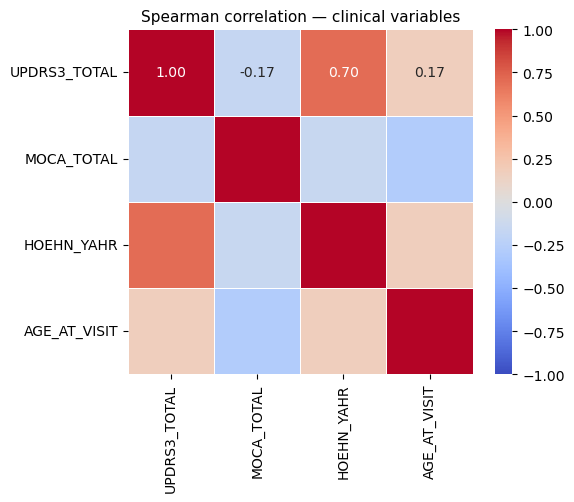

Saved: results/figures/clinical_correlation_beta_5e5.png


In [94]:
# INTER-CLINICAL-CORRELATION
corr_cols = [c for c in ['UPDRS3_TOTAL', 'MOCA_TOTAL', 'HOEHN_YAHR', 'AGE_AT_VISIT']
             if c in df_merged_train_copy.columns]

corr_matrix = df_merged_train_copy[corr_cols].corr(method='spearman')

print("=== Spearman correlation between clinical variables ===")
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Spearman correlation — clinical variables', fontsize=11)
plt.tight_layout()
plt.savefig('../../results/figures/clinical_correlation_beta_5e5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/clinical_correlation_beta_5e5.png")



In [95]:
# [ADD-SEX]
# Sex is already in df_match (loaded in Section 5)
# Add it via Image Data ID join

df_sex = df_match[['Image Data ID', 'Sex']].drop_duplicates()

df_merged_train_copy = df_merged_train_copy.merge(df_sex, on='Image Data ID', how='left')
df_merged_val_copy   = df_merged_val_copy.merge(df_sex,   on='Image Data ID', how='left')

print(f"Sex coverage train: {df_merged_train_copy['Sex'].notna().sum()} / {len(df_merged_train_copy)}")
print(f"Sex coverage val:   {df_merged_val_copy['Sex'].notna().sum()} / {len(df_merged_val_copy)}")

Sex coverage train: 3080 / 3085
Sex coverage val:   783 / 784


In [96]:
# [ADD-HANDEDNESS]
DEMO_FILE = os.path.join(CLINICAL_DIR, 'Demographics_30Jul2026.csv')

df_demo   = pd.read_csv(DEMO_FILE)
df_handed = df_demo[['PATNO', 'HANDED']].dropna(subset=['HANDED'])
df_handed = df_handed.drop_duplicates(subset=['PATNO'], keep='first')

df_merged_train_copy = df_merged_train_copy.merge(df_handed, on='PATNO', how='left')
df_merged_val_copy   = df_merged_val_copy.merge(df_handed,   on='PATNO', how='left')

print(f"Handedness coverage train: {df_merged_train_copy['HANDED'].notna().sum()} / {len(df_merged_train_copy)}")
print(f"Handedness coverage val:   {df_merged_val_copy['HANDED'].notna().sum()} / {len(df_merged_val_copy)}")

Handedness coverage train: 3081 / 3085
Handedness coverage val:   784 / 784


In [97]:
# [ADD-NP3-PCA]
# ─────────────────────────────────────────────────────────────────
# Source: notebook 5.3 (sbr_updrs_pca.ipynb)
# 
# NP3 PCA scores were computed in notebook 5.3 by running PCA on
# all 33 UPDRS-III individual items (OFF state, excluding NP3TOT).
# The fitted scaler and PCA objects are saved in results/models/.
#
# PC1 = overall motor severity (r=0.9973 with NP3TOT ✓)
# PC2 = laterality (right vs left symptom asymmetry)
# PC3 = additional variance
#
# We merge on PATNO + EVENT_ID with SC↔BL fallback — same approach
# as UPDRS-III — because NP3 scores come from the same clinical
# table and have the same SC/BL enrollment mismatch.
# ─────────────────────────────────────────────────────────────────

NP3_PCA_FILE = '../../results/models/np3_pca_scores.csv'
NP3_COLS     = ['NP3_PC1', 'NP3_PC2', 'NP3_PC3']

df_np3 = pd.read_csv(NP3_PCA_FILE)
df_np3 = df_np3[['PATNO', 'EVENT_ID'] + NP3_COLS].drop_duplicates(
    subset=['PATNO', 'EVENT_ID'], keep='first'
)

# SC↔BL swapped version
sc_bl_map      = {'SC': 'BL', 'BL': 'SC'}
df_np3_swapped = df_np3.copy()
df_np3_swapped['EVENT_ID'] = df_np3_swapped['EVENT_ID'].replace(sc_bl_map)
df_np3_swapped = df_np3_swapped.drop_duplicates(
    subset=['PATNO', 'EVENT_ID'], keep='first'
)

def merge_with_scbl(df, df_clin, cols, label):
    # Step 1 exact match
    merged = df.merge(df_clin[['PATNO', 'EVENT_ID'] + cols],
                      on=['PATNO', 'EVENT_ID'], how='left')
    n_exact = merged[cols[0]].notna().sum()
    # Step 2 SC↔BL fallback
    missing_mask = merged[cols[0]].isna()
    missing_rows = merged[missing_mask][['PATNO', 'EVENT_ID']].copy()
    fallback = missing_rows.merge(
        df_np3_swapped[['PATNO', 'EVENT_ID'] + cols],
        on=['PATNO', 'EVENT_ID'], how='left'
    )
    for col in cols:
        merged.loc[missing_mask.values, col] = fallback[col].values
    n_total = merged[cols[0]].notna().sum()
    print(f"  {label}: exact={n_exact}, SC↔BL={n_total-n_exact}, total={n_total}/{len(df)} ({n_total/len(df)*100:.1f}%)")
    return merged

print("=== NP3 PCA merge ===")
df_merged_train_copy = merge_with_scbl(df_merged_train_copy, df_np3, NP3_COLS, 'Train')
df_merged_val_copy   = merge_with_scbl(df_merged_val_copy,   df_np3, NP3_COLS, 'Val')

=== NP3 PCA merge ===
  Train: exact=1691, SC↔BL=808, total=2499/3085 (81.0%)
  Val: exact=431, SC↔BL=226, total=657/784 (83.8%)


In [98]:
# [ADD-SBR-PCA]
# ─────────────────────────────────────────────────────────────────
# Source: notebook 5.3 (sbr_updrs_pca.ipynb)
#
# SBR PCA scores were computed in notebook 5.3 by running PCA on
# 16 regional columns from the Xing Core Lab Quant SBR file.
# PC1 = overall dopamine signal (75.8%)
# PC2 = caudate vs putamen distinction (11.7%)
# PC3 = left-right asymmetry (3.7%)
#
# Coverage is ~69% because the Xing SBR file does not cover all
# patients in the latent files (known PPMI data limitation).
# Rows without a match will have NaN for SBR columns.
# ─────────────────────────────────────────────────────────────────

SBR_PCA_FILE = '../../results/models/sbr_xing_pca_scores.csv'
SBR_COLS     = ['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']

df_sbr = pd.read_csv(SBR_PCA_FILE)
df_sbr = df_sbr[['PATNO', 'EVENT_ID'] + SBR_COLS].drop_duplicates(
    subset=['PATNO', 'EVENT_ID'], keep='first'
)

df_merged_train_copy = df_merged_train_copy.merge(
    df_sbr, on=['PATNO', 'EVENT_ID'], how='left'
)
df_merged_val_copy = df_merged_val_copy.merge(
    df_sbr, on=['PATNO', 'EVENT_ID'], how='left'
)

n_train = df_merged_train_copy['SBR_XING_PC1'].notna().sum()
n_val   = df_merged_val_copy['SBR_XING_PC1'].notna().sum()

print(f"=== SBR PCA coverage ===")
print(f"  Train: {n_train} / {len(df_merged_train_copy)} ({n_train/len(df_merged_train_copy)*100:.1f}%)")
print(f"  Val:   {n_val} / {len(df_merged_val_copy)} ({n_val/len(df_merged_val_copy)*100:.1f}%)")

=== SBR PCA coverage ===
  Train: 2135 / 3085 (69.2%)
  Val:   567 / 784 (72.3%)


## 9. Save Final Files

In [99]:
# SAVE-FILES
df_merged_train_copy.to_csv(TRAIN_OUT, index=False)
df_merged_val_copy.to_csv(VAL_OUT,     index=False)

print("=== Files saved ===")
print(f"\nTrain: {TRAIN_OUT}")
print(f"  Shape:           {df_merged_train_copy.shape}")
print(f"  Unique patients: {df_merged_train_copy['PATNO'].nunique()}")
print(f"  Labels:          {df_merged_train_copy['label'].value_counts().to_dict()}")


print(f"\nVal: {VAL_OUT}")
print(f"  Shape:           {df_merged_val_copy.shape}")
print(f"  Unique patients: {df_merged_val_copy['PATNO'].nunique()}")
print(f"  Labels:          {df_merged_val_copy['label'].value_counts().to_dict()}")

print(f"\nClinical coverage (train):")
for col in ['UPDRS3_TOTAL', 'HOEHN_YAHR', 'MOCA_TOTAL']:
    if col in df_merged_train_copy.columns:
        pct = df_merged_train_copy[col].notna().mean() * 100
        print(f"  {col:<20} {pct:.1f}%")

=== Files saved ===

Train: ../../data/processed/clinical_merged/train_beta_5e5.csv
  Shape:           (3085, 275)
  Unique patients: 1678
  Labels:          {'PD': 2666, 'Control': 313, 'SWEDD': 106}

Val: ../../data/processed/clinical_merged/val_beta_5e5.csv
  Shape:           (784, 275)
  Unique patients: 420
  Labels:          {'PD': 688, 'Control': 65, 'SWEDD': 31}

Clinical coverage (train):
  UPDRS3_TOTAL         81.0%
  HOEHN_YAHR           81.0%
  MOCA_TOTAL           93.5%


## 10. Check SBR

In [100]:
# CHECK-SBR-COLUMNS
sbr_cols = [c for c in df_merged_train_copy.columns if 'DATSCAN' in c or 'SBR' in c]
print(f"SBR-related columns: {sbr_cols}")

SBR-related columns: ['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']


In [101]:
# CHECK-SAVED-FILE
import pandas as pd

df_check = pd.read_csv('../../data/processed/clinical_merged/train_beta_5e5.csv')
print(f"Shape: {df_check.shape}")
# print(f"Columns: {df_check.columns.tolist()}")
print(f"\nUPDRS3_TOTAL coverage: {df_check['UPDRS3_TOTAL'].notna().sum() if 'UPDRS3_TOTAL' in df_check.columns else 'COLUMN MISSING'}")

Shape: (3085, 275)

UPDRS3_TOTAL coverage: 2499
